# ReACT 기반 Single Agent 구현
- ReACT: Reasoning + Acting

create_agent(
    model = ..., 
    tools = [...], 
    middleware = [
        
    ]
)

## 1. API 연결

In [1]:
import os
from dotenv import load_dotenv

load_dotenv()

True

## 2. 도구 연결

In [ ]:
from langchain_core.tools import tool

@tool
def search(query: str) -> str:
    """
    주어진 쿼리로 정보를 검색합니다.
    최신 정보나 사실 확인이 필요할 때 사용하세요.
    
    Args:
        query (str): 검색할 질문이나 쿼리
    """
    # 목업, 돈 내기 싫으니까 가라로 한다고 생각하면 됨
    
    mock_results = {
        "Langgraph": "Langgraph는 LangSmith에서 제공하는 도구로, 다양한 도구 호출을 라우팅하여 복잡한 작업을 수행할 수 있게 해줍니다.",
        "ReACT": "ReACT는 Reasoning과 Acting을 결헙한 에이전트 패턴으로, LLM이 추론과 행동을 번갈아 수행합니다."
    }

    for key, value in mock_results.items():
        if key.lower() in query.lower():
            return value
    
    # 실제 검색 로직은 여기에 구현됩니다.
    return f"검색 결과 for '{query}'"


@tool
def calculator(expression: str) -> str:
    """
    수학 표현식을 계산합니다.

    Args:
    expression: 계산할 수학 표현식 (예: "2 + 3 * 4")
    """
    try:
        result = eval(expression)
        return f"{expression} = {result}"
    except Exception as e:
        return f"계산 오류: {str(e)}"

# 도구 리스트
tools = [search, calculator]

print("☑ 도구 정의 완료!")
print("- search: 정보 검색")
print("- calculator: 수학 계산")

☑ 도구 정의 완료!
- search: 정보 검색
- calculator: 수학 계산


## 3. 상태 정의

In [ ]:
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langgraph.graph import MessagesState
from operator import add

# MessagesState 사용 (messages 필드가 자동으로 누적됨)
# 또는 직접 정의할 수 있음:
class AgentState(TypedDict):
    messages: Annotated[list, add] # 메시지 누적
    iteration_count: int # 반복 횟수 추적 (선택적)


print("상태(State) 정의 완료!")
print("- messages: 대화 메시지 리스트")
print("- iteration_count: ReACT 루프 반복 횟수")

상태(State) 정의 완료!
- messages: 대화 메시지 리스트
- iteration_count: ReACT 루프 반복 횟수


## 4. 노드 함수 구현

1. call_model:LLM 호출 -> 추론 (즉, 도구 호출 결정)
2. should_continue: 도구 호출 필요 판단

In [6]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from langgraph.prebuilt import ToolNode

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)
llm_with_tools = llm.bind_tools(tools=tools)

# 시스템 프롬프트
SYSTEM_PROMPT = """You are a helpful assistant with access to tools.
Use the available tools to answer user questions.
Think step by step and use tools when needed.
Always respond in Korean."""

def call_model(state: MessagesState):
    """LLM을 호출하여 응답 또는 도구 호출 결정"""
    print("LLM 호출 중...")

    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    response = llm_with_tools.invoke(messages)

    return {"messages": [response]} # 메시지 누적

def should_continue(state: MessagesState) -> Literal["tools", "__end__"]:
    """LLM 호출 여부 판단"""
    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        print("---도구 호출 필요---")
        return "tools"
    
    print("---응답 완료---")
    return "__end__"


tools_node = ToolNode(tools=tools)
print("노드 함수 구현 완료")


노드 함수 구현 완료


## 5. 그래프 구성 및 컴파일

ReACT 에이전트의 그래프 구조:
<pre>
START → call_model → [tool_calls 있음?]
                     → Yes: tools → call_model (loop)
                     → No: END
</pre>

In [ ]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(MessagesState)

workflow.add_node("call_model", call_model)
workflow.add_node("tools", tools_node)

workflow.add_edge(START, "call_model")

workflow.add_conditional_edges(
    "call_model", # 시작 노드
    should_continue, # 분기하는 로직
    {
        "tools": "tools",
        "__end__": END
    }
)

workflow.add_edge("tools", "call_model")

react_agent = workflow.compile()

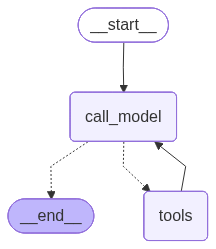

In [11]:
from IPython.display import display, Image

try:
    display(Image(react_agent.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"그래프 시각화 오류: {str(e)}")

## 6. 그래프 에이전트 실행

In [12]:
# 테스트 1: 일반 대화(도구 호출 없음)
test1 = "안녕하세요! 반갑습니다."

print(f"질문: {test1}")
print("=" * 50)

result = react_agent.invoke({"messages": [{"role": "user", "content": test1}]})
print(f"답변: {result['messages'][-1].content}")

질문: 안녕하세요! 반갑습니다.
LLM 호출 중...
---응답 완료---
답변: 안녕하세요! 반갑습니다. 어떻게 도와드릴까요?


In [ ]:
# 테스트 2: 검색 도구 호출
test2 = "LangGraph가 뭔지 검색해서 알려줘"

print(f"● 질문: {test2}")
print("=" * 50)

result = react_agent.invoke({"messages": [{"role": "user", "content": test2}]})
print(f"\n답변:\n{result['messages'][-1].content}")

● 질문: LangGraph가 ·뭔지·검색해서 알려줘
LLM 호출 중...
---도구 호출 필요---
LLM 호출 중...
---응답 완료---

답변:
LangGraph는 LangSmith에서 제공하는 도구로, 다양한 도구 호출을 라우팅하여 복잡한 작업을 수행할 수 있게 해주는 도구입니다.


In [15]:
# 테스트 3: 계산 도구 호출
test3 = "(15 + 27) * 2를 계산해줘"

print(f"● 질문: {test3}")
print("=" * 50)

result = react_agent.invoke({"messages": [{"role": "user", "content": test3}]})
print(f"\n답변:\n{result['messages'][-1].content}")

● 질문: (15 + 27) * 2를 계산해줘
LLM 호출 중...
---도구 호출 필요---
LLM 호출 중...
---응답 완료---

답변:
(15 + 27) * 2의 계산 결과는 84입니다.


In [17]:
# stream 방식
test4 = "ReACT 패턴에 대해 검색하고 설명해줘"

print(f"● 질문: {test4}")
print("=" * 50)


for chunk in react_agent.stream({"messages": [{"role": "user", "content": test4}]}):
    for node_name, value in chunk.items():
        print(f"\n? [{node_name}] 노드 실행")

        if "messages" in value and value["messages"]:
            last_msg = value["messages"][-1]

            if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                for tc in last_msg.tool_calls:
                    print(f" Tool: {tc['name']}({tc['args']})")
            elif hasattr(last_msg, 'content') and last_msg.content:
                if node_name == "tools":
                    print(f"결과: {last_msg.content[:100]} ... ")
                else:
                    print(f"\n최종 답변:\n{last_msg.content}")

● 질문: ReACT 패턴에 대해 검색하고 설명해줘
LLM 호출 중...
---도구 호출 필요---

? [call_model] 노드 실행
 Tool: search({'query': 'ReACT 패턴'})

? [tools] 노드 실행
결과: ReACT는 Reasoning과 Acting을 결헙한 에이전트 패턴으로, LLM이 추론과 행동을 번갈아 수행합니다. ... 
LLM 호출 중...
---응답 완료---

? [call_model] 노드 실행

최종 답변:
ReACT 패턴은 Reasoning(추론)과 Acting(행동)을 결합한 에이전트 패턴입니다. 이 패턴에서는 대형 언어 모델(LLM)이 추론과 행동을 번갈아 수행하면서 문제를 해결합니다. 즉, 모델이 먼저 상황을 분석하고 추론한 후, 그에 맞는 행동을 취하는 과정을 반복하는 방식입니다. 이를 통해 더 효과적이고 유연한 문제 해결이 가능해집니다.
